In [1]:
import s3fs

In [2]:
# S3 Configuration
bucket = "llc/"
folder = "native_grid_dbof_training_data/"
run_id = "parallel_test/"

s3_endpoint = "https://s3-west.nrp-nautilus.io"

In [3]:
!aws --endpoint https://s3-west.nrp-nautilus.io s3 ls s3://dbof/native_grid_dbof_training_data/global_20121109_120000/ --human-readable

                           PRE frontal_structure.zarr/
                           PRE frontogenesis.zarr/
                           PRE kinematic.zarr/
                           PRE native_fields.zarr/


In [4]:
import dbof.io.filesystems as filesystems
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

In [5]:
from dbof.dataset_creation.zarr_dataset_global import GlobalZarrDatasetReader

reader = GlobalZarrDatasetReader("dbof/", "native_grid_dbof_training_data", "global_20121109_120000", "native_fields.zarr", fs)

# grid_reader = GlobalGridZarrReader("dbof/", "native_grid_dbof_training_data/global_20121109_120000/", "frontal_structure.zarr", fs)

In [6]:
reader.n_timesteps

1

In [7]:
reader.n_channels

6

In [8]:
reader.channel_names

['Theta', 'Salt', 'Eta', 'U', 'V', 'W']

In [9]:
theta = reader.get_channel_snapshot(0, 'Theta')
print(theta.shape)
print(type(theta))

(12960, 17280)
<class 'numpy.ndarray'>


In [10]:
full_snap = reader.get_snapshot(0)

In [11]:
type(full_snap)

numpy.ndarray

In [12]:
full_snap.shape

(6, 12960, 17280)

In [24]:
import cmocean
import matplotlib.pyplot as plt
def plot_stitched_faces(ds, color_map = cmocean.cm.thermal, vmin=None, vmax=None, is_mask=False):
    if vmin is None:
        # find vmin and max for plot
        vmin = ds.min().compute()
        vmax = ds.max().compute()

    fig = plt.figure()
    mappable= ds.plot(cmap=color_map, vmin=vmin, vmax=vmax)

    if mappable is not None:
        cbar = fig.colorbar(mappable, orientation="horizontal", fraction=0.05, pad=0.05)
        cbar.set_label(ds.name if hasattr(ds, "name") else "")

    plt.tight_layout()
    plt.show()

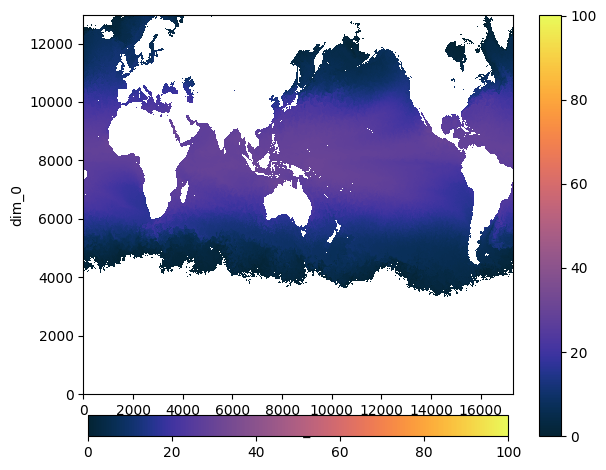

In [25]:
#import dbof.plotting.llc_plotting as llc_plotting
import xarray as xr

#xr.DataArray(theta).plot()

plot_stitched_faces(xr.DataArray(theta), vmin=0, vmax= 100) #, color_map = cmocean.cm.thermal, vmin=None, vmax=None, is_mask=False)